### Package Installation

In [ ]:
%pip install qiskit-machine-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.9 MB/s eta 0:00:00


In [ ]:
# require additional packages (as of 1/1/2026)
%pip install pylatexenc # visualizaer for LaTeX math expression (required to map this on to q. circuit)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=53f01a5ea330397b7a211f9c3537bf2e3c279609f2a134b85709d5ab1f31b04c
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


#### Imports

In [ ]:
import os
import zipfile
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import clear_output

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import z_feature_map, zz_feature_map

from qiskit.primitives import StatevectorSampler as Sampler

from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
algorithm_globals.random_seed = 12345
sampler = Sampler()

### Dataset Processing

#### Load dataset

In [ ]:
ZIP_PATH = "generated_icons_v2.zip"
DATA_DIR = "generated_icons_v2"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DATA_DIR)

print(f"Unzipped dataset to: {DATA_DIR}")

Unzipped dataset to: generated_icons_v2


In [ ]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "angle_train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "angle_test.csv"))

In [ ]:
pixel_cols = [f"pix{i}" for i in range(16)] # List to store the for 5x5 input data

In [ ]:
X_train = train_df[pixel_cols].values
X_test = test_df[pixel_cols].values

In [ ]:
y_train = train_df["label_id"].values
y_test = test_df["label_id"].values

In [ ]:
class_names = ["cross", "square", "triangle", "x"]

In [ ]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train labels:", np.bincount(y_train))
print("Test labels:", np.bincount(y_test))

Train shape: (280, 16)
Test shape: (120, 16)
Train labels: [70 70 70 70]
Test labels: [30 30 30 30]


#### Visualize original 4x4 examples

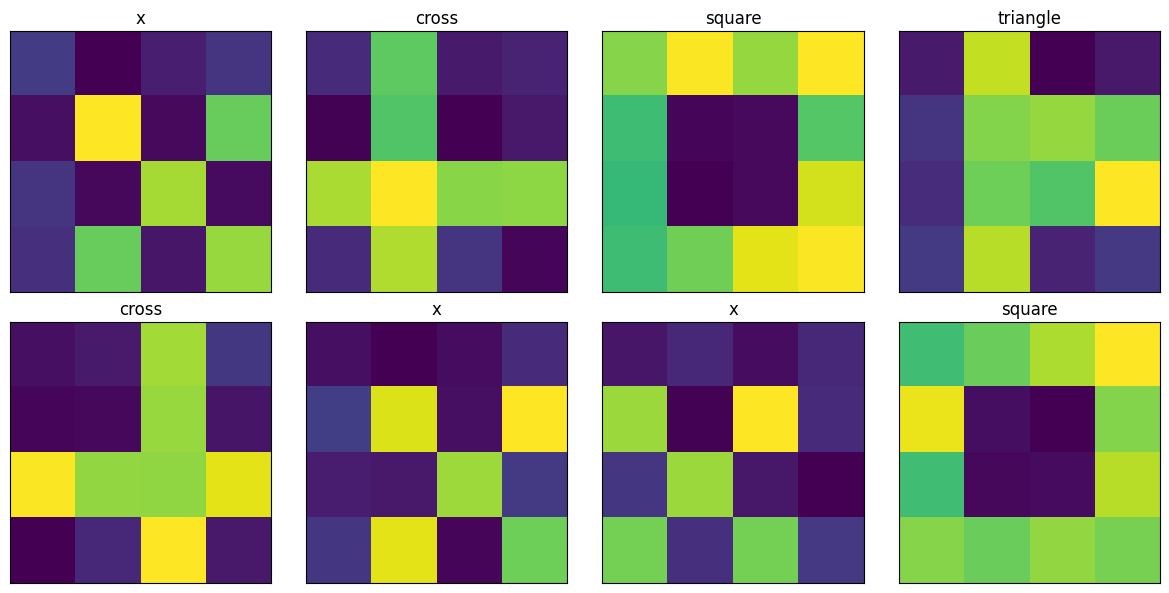

In [ ]:
fig, ax = plt.subplots(2, 4, figsize=(12, 6), subplot_kw={"xticks": [], "yticks": []})

for i in range(8):
    ax[i // 4, i % 4].imshow(X_train[i].reshape(4, 4), aspect="equal")
    ax[i // 4, i % 4].set_title(class_names[y_train[i]])

plt.tight_layout()
plt.show()

### Convolutional Layer

#### Convolution Circuit

In [ ]:
def conv_circuit(params):
    """Three-parameter two-qubit unitary block used for convolution."""
    target = QuantumCircuit(2)
    target.rz(-np.pi / 2, 1) # input a negative pi/2 on the second qubit (q1) - # Apply a fixed Rz(-π/2) rotation to q1
    target.cx(1, 0) # (control q, target q), ie, q0 becomes target, q1 becomes control
    target.rz(params[0], 0) # rotate q0 by value of params[0] based on z axis -> learnable parameters in QML
    target.ry(params[1], 1) # rotate q1 by value of params[1] based on y axis -> learnable parameters in QML
    target.cx(0, 1) # (control q, target q), ie, q0 becomes control, q1 becomes target
    target.ry(params[2], 1) # rotate q1 by value of params[2] based on y axis -> learnable parameters in QML
    target.cx(1, 0) # (control q, target q), ie, q1 becomes control, q0 becomes target
    target.rz(np.pi / 2, 0) # input a positive pi/2 on the first qubit (q0) - # Fixed rotation on q0
    return target

#### Shared Convolution Layer

In [ ]:
def conv_layer_shared(num_qubits, param_prefix):
    """
    Convolutional layer with parameter sharing.

    All two-qubit convolution blocks within this layer share
    the same 3 trainable parameters.
    """
    qc = QuantumCircuit(num_qubits, name="Shared Convolutional Layer")
    qubits = list(range(num_qubits))

    # Only 3 parameters for the entire convolutional layer
    params = ParameterVector(param_prefix, length=3)

    # Even pairs: (0,1), (2,3), ...
    for q1, q2 in zip(qubits[0::2], qubits[1::2]):
        qc = qc.compose(conv_circuit(params), [q1, q2]) # Repeat θ[0], θ[1], θ[2] (parameter sharing)
        qc.barrier()

    # Odd/circular pairs: (1,2), (3,4), ..., (last,0)
    for q1, q2 in zip(qubits[1::2], qubits[2::2] + [0]):
        qc = qc.compose(conv_circuit(params), [q1, q2]) # Repeat θ[0], θ[1], θ[2] (parameter sharing)
        qc.barrier()

    qc_inst = qc.to_instruction()

    qc = QuantumCircuit(num_qubits)
    qc.append(qc_inst, qubits)

    return qc

### Pooling Layer

#### Pooling Circuit

In [ ]:
def pool_circuit(params):
    """Three-parameter two-qubit unitary block used for pooling."""
    target = QuantumCircuit(2)
    target.rz(-np.pi / 2, 1)
    target.cx(1, 0)
    target.rz(params[0], 0)
    target.ry(params[1], 1)
    target.cx(0, 1)
    target.ry(params[2], 1)

    return target

#### Shared Pooling Layer

In [ ]:
def pool_layer_shared(sources, sinks, param_prefix):
    """
    Pooling layer with parameter sharing.

    All source-sink pooling blocks within this pooling layer
    share the same 3 trainable parameters.
    """
    num_qubits = len(sources) + len(sinks)

    qc = QuantumCircuit(num_qubits, name="Shared Pooling Layer")

    # Only 3 parameters for the entire pooling layer
    params = ParameterVector(param_prefix, length=3) # Fixed length of 3. Will be shared.

    for source, sink in zip(sources, sinks):
        qc = qc.compose(pool_circuit(params), [source, sink]) # Repeat θ[0], θ[1], θ[2] (parameter sharing)
        qc.barrier()

    qc_inst = qc.to_instruction()

    qc = QuantumCircuit(num_qubits)
    qc.append(qc_inst, range(num_qubits))

    return qc

### Building Ansatz

In [ ]:
def build_qcnn_ansatz_16_to_2():

  feature_map = z_feature_map(16) # feature_map = data encoding

  ansatz = QuantumCircuit(16, name="Ansatz") # ansatz = trainable model

  # First Convolutional Layer
  ansatz.compose(conv_layer_shared(16, "c1"), list(range(16)), inplace=True) # Apply convolution layer over all the 16 qubits.

  # First Pooling Layer
  ansatz.compose(pool_layer_shared([0, 1, 2, 3, 4, 5, 6, 7],
                            [8, 9, 10, 11, 12, 13, 14, 15], "p1"), list(range(16)), inplace=True) # sources = 0-7, sinks = 8-15
  # Second Convolutional Layer
  ansatz.compose(conv_layer_shared(8, "c2"), list(range(8, 16)), inplace=True) # Now active qubits are only q8-q15. Building conv_layer(8, "c2") for them.

  # Second Pooling Layer
  ansatz.compose(pool_layer_shared([0, 1, 2, 3], [4, 5, 6, 7], "p2"), list(range(8, 16)), inplace=True)

  # Third Convolutional Layer
  ansatz.compose(conv_layer_shared(4, "c3"), list(range(12, 16)), inplace=True)

  # Third Pooling Layer
  ansatz.compose(pool_layer_shared([0, 1], [2, 3], "p3"), list(range(12, 16)), inplace=True) # Final 2 active qubits

  return ansatz

### Building Quantum Circuit (Merging feature map and ansatz)

In [ ]:
feature_map = z_feature_map(16)
ansatz = build_qcnn_ansatz_16_to_2()

In [ ]:
# Combining the feature map and ansatz
circuit = QuantumCircuit(16)
circuit.compose(feature_map, range(16), inplace=True)
circuit.compose(ansatz, range(16), inplace=True)

### Building SamplerQNN

In [ ]:
# Interpret function for 4 classes
def interpret_2_output_qubits(x):
    """
    Map the measured bitstring integer to one of 4 classes
    using output qubits q14 and q15.

    00 -> 0 cross
    01 -> 1 square
    10 -> 2 triangle
    11 -> 3 x
    """
    bit_q14 = (x >> 14) & 1
    bit_q15 = (x >> 15) & 1

    return bit_q14 + 2 * bit_q15

In [ ]:
qnn = SamplerQNN(
    circuit=circuit.decompose(),
    sampler=sampler,                     # SamplerQNN for multi-class classification
    input_params=feature_map.parameters, # Non-trainable parameters for input data
    weight_params=ansatz.parameters,     # Trainable parameters, ie., params in convolution/pooling layers. Will be optimized by optimizer.
    interpret=interpret_2_output_qubits,
    output_shape=4
)

Number of trainable parameters: 18


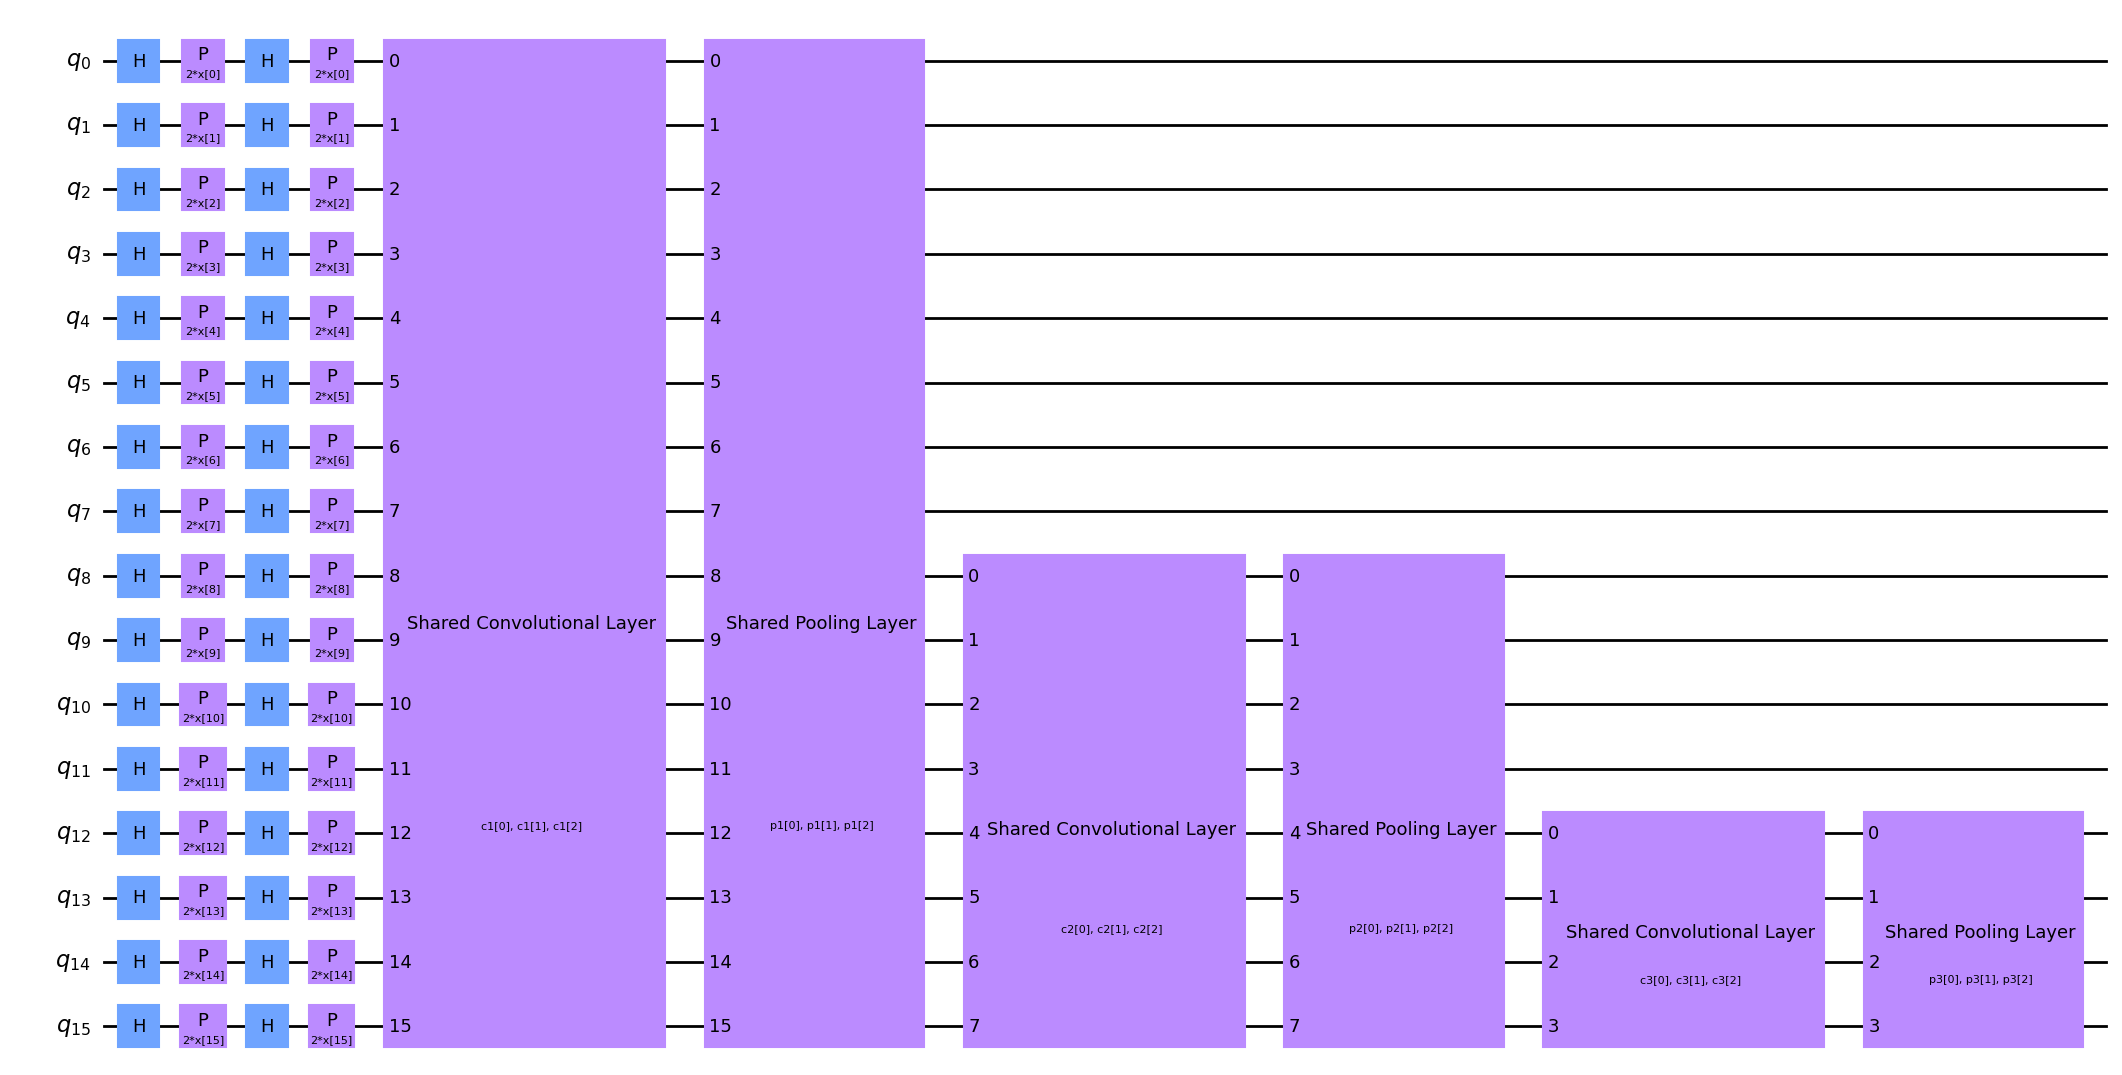

In [ ]:
print("Number of trainable parameters:", len(ansatz.parameters))
circuit.draw("mpl", style="clifford", fold=120)

### Building Neural Network Classifier

In [ ]:
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval) # Keeps storing loss values in a list.
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

In [ ]:
classifier = NeuralNetworkClassifier( # Wrapping the SamplerQNN as classifier, which can be used like scikit-learn models.
    qnn,
    optimizer=COBYLA(maxiter=20),  # Set max iterations here
    callback=callback_graph,
    # initial_point=initial_point, # For loading pretrained weights
    one_hot=False
)

### Training our QCNN (Neural Network Classifier)

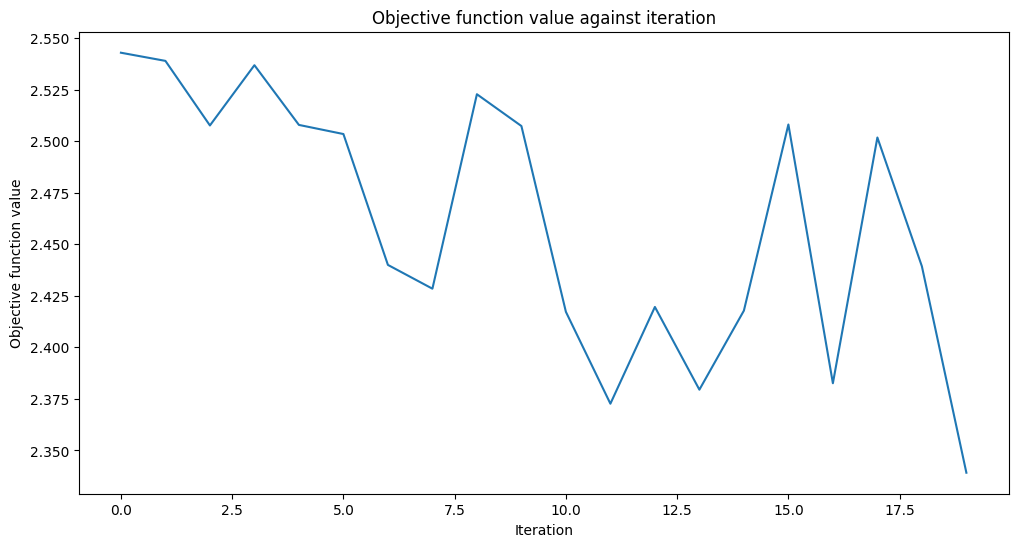

Train accuracy: 37.50%
Accuracy from the train data : 37.5%


In [ ]:
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)
classifier.fit(X_train, y_train) # Start classifier training

train_score = classifier.score(X_train, y_train)

print(f"Train accuracy: {train_score * 100:.2f}%")

# score classifier
print(f"Accuracy from the train data : {np.round(100 * classifier.score(X_train, y_train), 2)}%") # Accuracy from the train data

In [ ]:
trained_weights = classifier.weights

with open("qcnn_4x4_shared_weights.json", "w") as f:
    json.dump(trained_weights.tolist(), f)

# # For loading the trained weights
# with open("qcnn_4x4_shared_weights.json", "w") as f:
#     json.dump(classifier.weights.tolist(), f, indent=4)

print("Saved trained weights to qcnn_4x4_shared_weights.json")

Saved trained weights to qcnn_4x4_shared_weights.json


### Testing our QCNN (Neural Network Classifier)

Test accuracy: 33.33%
Classification report:
              precision    recall  f1-score   support

       cross       0.45      0.43      0.44        30
      square       0.50      0.53      0.52        30
    triangle       0.22      0.33      0.27        30
           x       0.07      0.03      0.05        30

    accuracy                           0.33       120
   macro avg       0.31      0.33      0.32       120
weighted avg       0.31      0.33      0.32       120



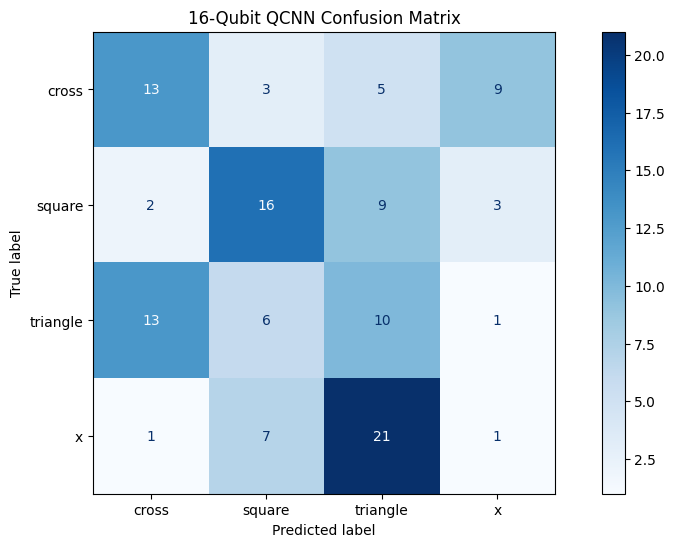

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = classifier.predict(X_test)

test_score = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_score * 100:.2f}%")

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("16-Qubit QCNN Confusion Matrix")
plt.show()

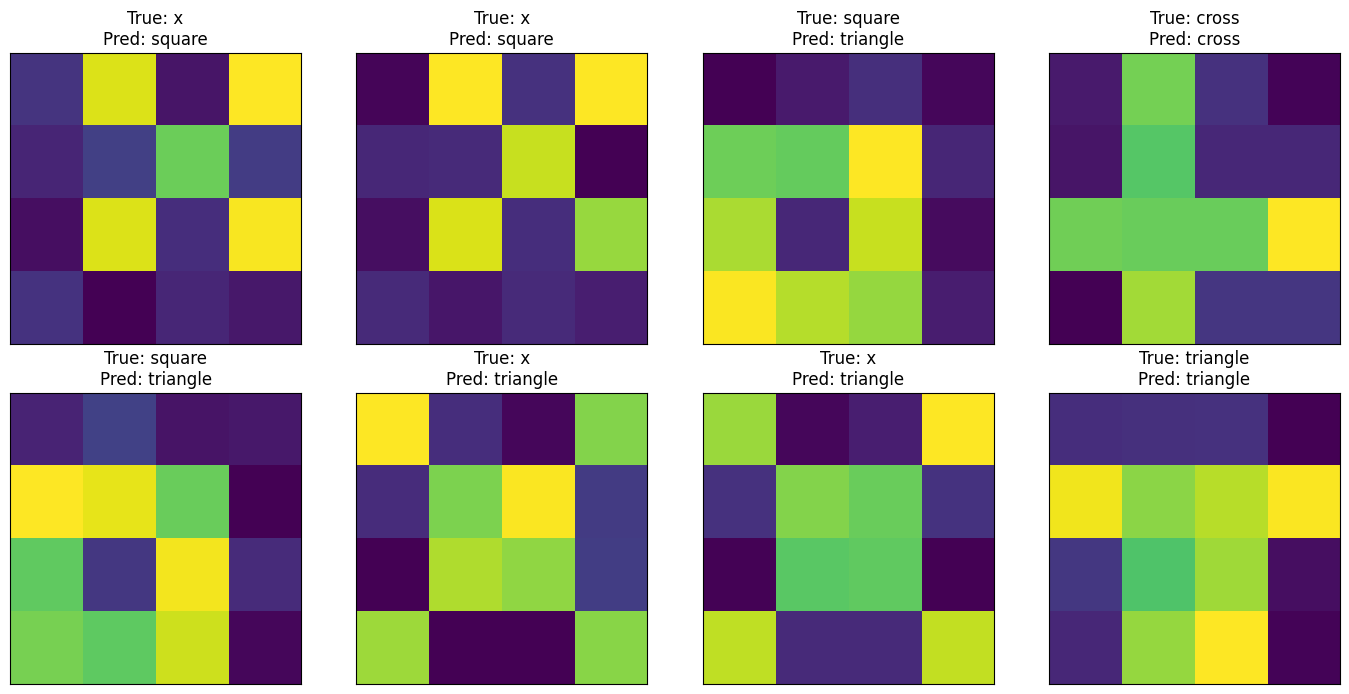

In [ ]:
# Let's see some examples in our dataset
fig, ax = plt.subplots(2, 4, figsize=(14, 7), subplot_kw={"xticks": [], "yticks": []})
for i in range(8):
    ax[i // 4, i % 4].imshow(X_test[i].reshape(4, 4), aspect="equal")

    true_label = class_names[y_test[i]]
    pred_label = class_names[y_pred[i]]

    ax[i // 4, i % 4].set_title(f"True: {true_label}\nPred: {pred_label}")

plt.tight_layout()
plt.show()

In [ ]:
# Save final results and weights
results = {
    "model": "16-qubit shared-parameter QCNN",
    "train_accuracy": float(train_score),
    "test_accuracy": float(test_score),
    "maxiter": 20,
    "num_trainable_parameters": int(len(ansatz.parameters)),
    "input_features": 16,
    "classes": class_names,
    "training_time_min": float(125)
}

with open("qcnn_4x4_shared_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Saved qcnn_4x4_shared_results.json")

Saved qcnn_4x4_shared_results.json
